<a href="https://colab.research.google.com/github/zeeldhorajiya1909/codsoft_tasks/blob/main/codsoft_task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import the os module to handle file paths

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix



In [9]:
# --- Step 1: Load the Dataset ---
import kagglehub

dataset_path = kagglehub.dataset_download("shantanudhakadd/bank-customer-churn-prediction")

print("Path to dataset files:", dataset_path)


csv_file_name = 'Churn_Modelling.csv'
full_csv_path = os.path.join(dataset_path, csv_file_name)

# Read the CSV file into a pandas DataFrame
data = pd.read_csv(full_csv_path)
print(data.head())
print(data.info())

Using Colab cache for faster access to the 'bank-customer-churn-prediction' dataset.
Path to dataset files: /kaggle/input/bank-customer-churn-prediction
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   Es

In [10]:
# --- Step 2: Data Preprocessing ---
# Identify target variable and features
target = 'Exited' # Assuming 'Exited' is the name of your target column
features = data.drop(columns=[target])

# Identify categorical and numerical features
numerical_features = features.select_dtypes(include=np.number).columns
categorical_features = features.select_dtypes(include='object').columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
     ('scaler', StandardScaler())
 ])

categorical_transformer = Pipeline(steps=[
     ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
     transformers=[
         ('num', numerical_transformer, numerical_features),
         ('cat', categorical_transformer, categorical_features)
    ])

# Split data into training and testing sets
X = features
y = data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.82      0.95      0.88      1593
           1       0.50      0.20      0.29       407

    accuracy                           0.80      2000
   macro avg       0.66      0.57      0.58      2000
weighted avg       0.76      0.80      0.76      2000

Accuracy: 0.797


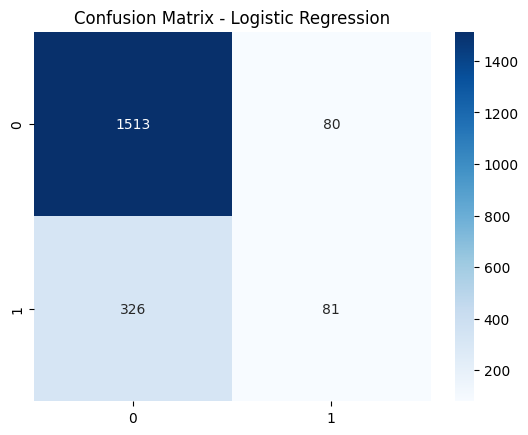


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      1593
           1       0.86      0.35      0.50       407

    accuracy                           0.86      2000
   macro avg       0.86      0.67      0.71      2000
weighted avg       0.86      0.86      0.83      2000

Accuracy: 0.8565


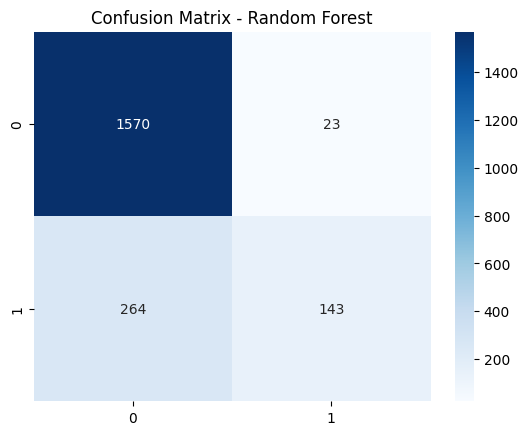


--- Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000

Accuracy: 0.863


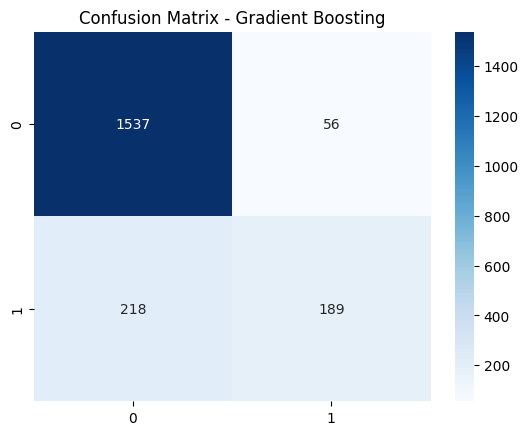

In [11]:
# --- Step 3: Model Training and Evaluation ---
# 1. Logistic Regression
print("\n--- Logistic Regression ---")
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

# 2. Random Forest
print("\n--- Random Forest ---")
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# 3. Gradient Boosting
print("\n--- Gradient Boosting ---")
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])
pipeline_gb.fit(X_train, y_train)
y_pred_gb = pipeline_gb.predict(X_test)
print(classification_report(y_test, y_pred_gb))
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()